# Linear Regression


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error , root_mean_squared_error

In [4]:
df = pd.read_csv("powerplant_data.csv")

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
print(df.head(10))
df.shape

      AT      V       AP     RH      PE
0   8.34  40.77  1010.84  90.01  480.48
1  23.64  58.49  1011.40  74.20  445.75
2  29.74  56.90  1007.15  41.91  438.76
3  19.07  49.69  1007.22  76.79  453.09
4  11.80  40.66  1017.13  97.20  464.43
5  13.97  39.16  1016.05  84.60  470.96
6  22.10  71.29  1008.20  75.38  442.35
7  14.47  41.76  1021.98  78.41  464.00
8  31.25  69.51  1010.25  36.83  428.77
9   6.77  38.18  1017.80  81.13  484.31


(9568, 5)

In [7]:
X = df.drop(columns="PE")
y = df["PE"]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


# EDA


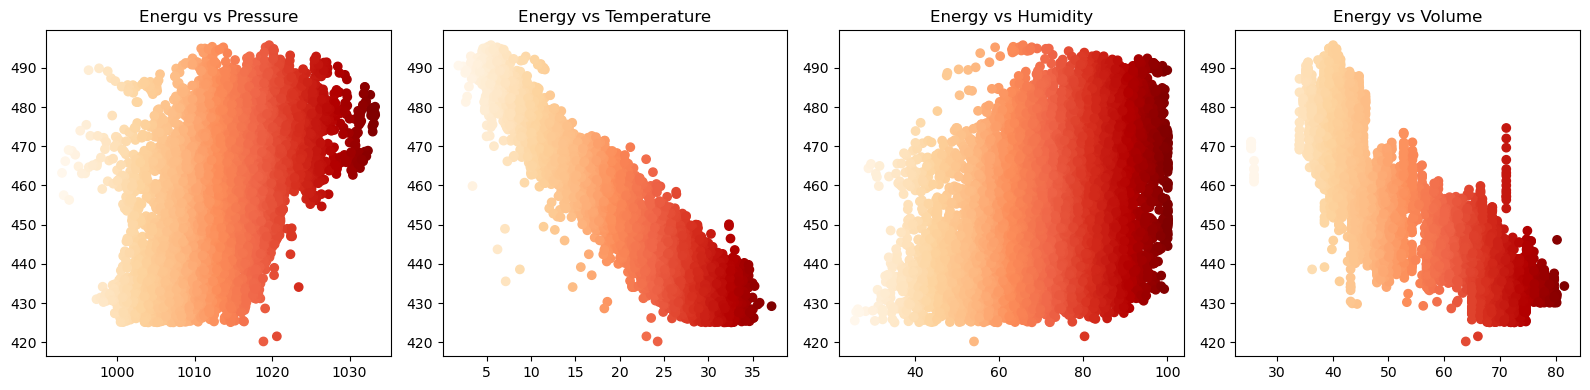

In [9]:
pe = df["PE"]

ap = df["AP"]
at = df["AT"]
rh = df["RH"]
v = df["V"]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].scatter(ap, pe, c=ap, cmap="OrRd")
axs[0].set_title("Energu vs Pressure")
axs[1].scatter(at, pe, c=at, cmap="OrRd")
axs[1].set_title("Energy vs Temperature")
axs[2].scatter(rh, pe, c=rh, cmap="OrRd")
axs[2].set_title("Energy vs Humidity")
axs[3].scatter(v, pe, c=v, cmap="OrRd")
axs[3].set_title("Energy vs Volume")


plt.tight_layout()

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

In [47]:
model1.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = model1.predict(X_test)

In [49]:
y_train_pred = model1.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train R_sq : {train_r2}")
print(f"Test R_sq : {r2_score(y_test,y_pred)}")

Train R_sq : 0.9279951490925766
Test R_sq : 0.931474793667036


In [50]:
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred)}")
print(f"MSE : {mean_squared_error(y_test,y_pred)}")
print(f"R^2 Score : {r2_score(y_test,y_pred)}")

MAE : 3.5434484970790163
RMSE : 4.428101774539947
MSE : 19.608085325683827
R^2 Score : 0.931474793667036


# KNN

In [51]:
from sklearn.neighbors import KNeighborsRegressor

In [52]:
model2 = KNeighborsRegressor()

In [53]:
model2.fit(X_train,y_train)

KNeighborsRegressor()

In [54]:
y_pred = model2.predict(X_test)


y_train_pred = model2.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train R_sq : {train_r2}")
print(f"Test R_sq : {r2_score(y_test,y_pred)}")

Train R_sq : 0.9642582696291364
Test R_sq : 0.9471773077666277


In [55]:
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred)}")
print(f"MSE : {mean_squared_error(y_test,y_pred)}")
print(f"R^2 Score : {r2_score(y_test,y_pred)}")

MAE : 2.8773615464994773
RMSE : 3.887788978463958
MSE : 15.114903141065826
R^2 Score : 0.9471773077666277


# Using GridSearchCV

In [56]:
from sklearn.model_selection import GridSearchCV

regressor = KNeighborsRegressor()

param_grid = {"n_neighbors": [1, 3, 5, 7, 9, 11]}

RegressorCV = GridSearchCV(
    regressor,
    param_grid,
    cv = 5,
    scoring="r2"
)


RegressorCV.fit(X_train,y_train)

y_pred1 = RegressorCV.predict(X_test)

y_train_pred1 = RegressorCV.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred1)

print(f"Train R_sq : {train_r2}")
print(f"Test R_sq : {r2_score(y_test,y_pred1)}")

print("\n\n")

print(f"MAE : {mean_absolute_error(y_test,y_pred1)}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred1)}")
print(f"MSE : {mean_squared_error(y_test,y_pred1)}")
print(f"R^2 Score : {r2_score(y_test,y_pred1)}")

print("\n\n")


print(RegressorCV.best_params_) # Since the best value is 5 , The Evaluation metrics are same again

Train R_sq : 0.9642582696291364
Test R_sq : 0.9471773077666277



MAE : 2.8773615464994773
RMSE : 3.887788978463958
MSE : 15.114903141065826
R^2 Score : 0.9471773077666277



{'n_neighbors': 5}


# Using StandardScaler

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [58]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
model1.fit(X_train_scaled,y_train)

LinearRegression()

In [60]:
y_pred = model1.predict(X_test_scaled)

y_train_pred = model1.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)


print(f"Train R_sq : {train_r2}")
print(f"Test R_sq : {r2_score(y_test,y_pred)}")

print("\n\n")

print(f"MAE : {mean_absolute_error(y_test,y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred)}")
print(f"MSE : {mean_squared_error(y_test,y_pred)}")
print(f"R^2 Score : {r2_score(y_test,y_pred)}")

Train R_sq : 0.9279951490925766
Test R_sq : 0.9314747936670361



MAE : 3.543448497079016
RMSE : 4.428101774539946
MSE : 19.60808532568382
R^2 Score : 0.9314747936670361


In [62]:
model2.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [63]:
y_pred = model2.predict(X_test_scaled)

y_train_pred = model2.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)


print(f"Train R_sq : {train_r2}")
print(f"Test R_sq : {r2_score(y_test,y_pred)}")

print("\n\n")

print(f"MAE : {mean_absolute_error(y_test,y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred)}")
print(f"MSE : {mean_squared_error(y_test,y_pred)}")
print(f"R^2 Score : {r2_score(y_test,y_pred)}")

Train R_sq : 0.9673065853726502
Test R_sq : 0.9521517965621104



MAE : 2.7067304075235112
RMSE : 3.7002003173767135
MSE : 13.69148238871473
R^2 Score : 0.9521517965621104
